<a href="https://colab.research.google.com/github/Hank-777/Repos/blob/CREDIT-CARD/cred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape of dataset: (223858, 31)
Class
0.0    223442
1.0       415
Name: count, dtype: int64


/tmp/ipython-input-3-1047582969.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=data, palette='Set2')


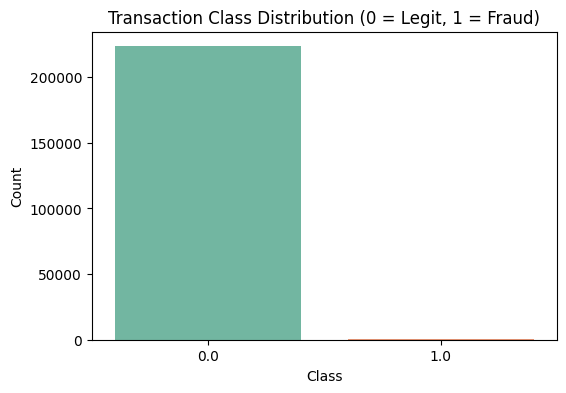

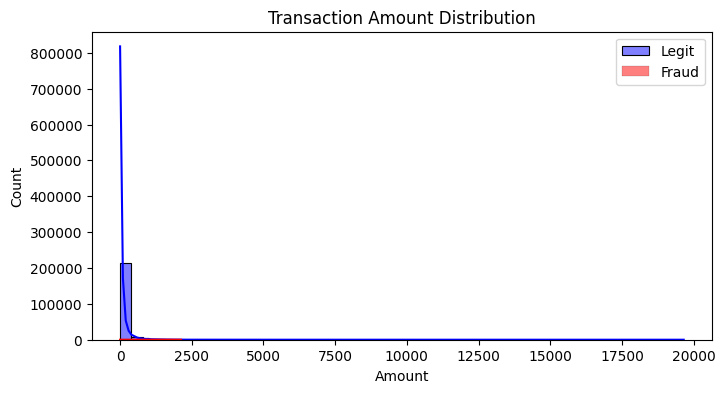

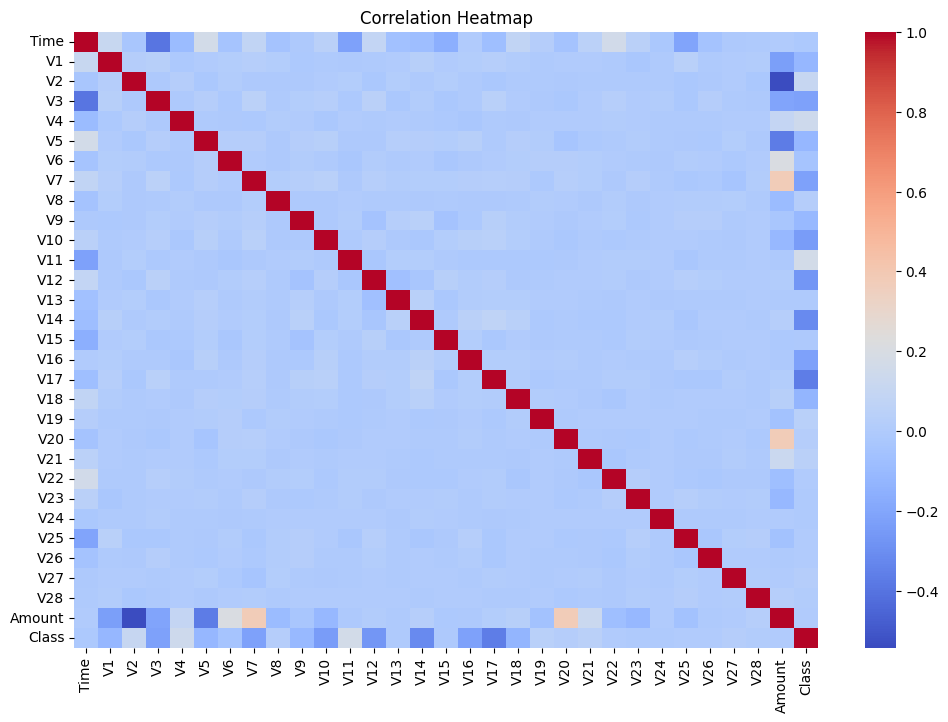

✅ Accuracy: 0.9995309568480301

✅ Classification Report:
               precision    recall  f1-score   support

         0.0     0.9996    1.0000    0.9998     44689
         1.0     0.9844    0.7590    0.8571        83

    accuracy                         0.9995     44772
   macro avg     0.9920    0.8795    0.9285     44772
weighted avg     0.9995    0.9995    0.9995     44772



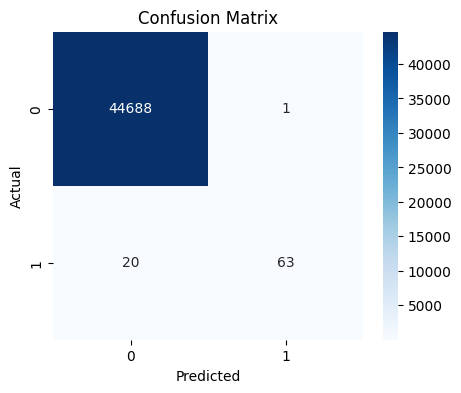

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Load dataset
data = pd.read_csv('creditcard.csv')  # Replace with your dataset path

# Basic stats
print("Shape of dataset:", data.shape)
print(data['Class'].value_counts())

# -------------------------
# 1. PLOT: Class Distribution
# -------------------------
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=data, palette='Set2')
plt.title("Transaction Class Distribution (0 = Legit, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

# -------------------------
# 2. PLOT: Amount Distribution (Fraud vs Legit)
# -------------------------
plt.figure(figsize=(8, 4))
sns.histplot(data[data['Class'] == 0]['Amount'], bins=50, color='blue', label='Legit', kde=True)
sns.histplot(data[data['Class'] == 1]['Amount'], bins=50, color='red', label='Fraud', kde=True)
plt.legend()
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.show()

# -------------------------
# 3. Scale Amount & Time
# -------------------------
scaler = StandardScaler()
data['Amount'] = scaler.fit_transform(data[['Amount']])
data['Time'] = scaler.fit_transform(data[['Time']])

# -------------------------
# Handle missing values in 'Class' column AFTER scaling
# -------------------------
data.dropna(subset=['Class'], inplace=True)


# -------------------------
# 4. PLOT: Correlation Heatmap
# -------------------------
corr = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

# -------------------------
# 5. Model Training
# -------------------------
X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# -------------------------
# 6. Evaluation
# -------------------------
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n✅ Classification Report:\n", classification_report(y_test, y_pred, digits=4))

# -------------------------
# 7. PLOT: Confusion Matrix
# -------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()